# Visualize Nonlinear Causal Effects Estimated by Longitudinal RESIT with a Shared Causal Structure Across All Time Points

## Import and settings

In this example, we need to import numpy, pandas, and graphviz in addition to lingam.

In [1]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import graphviz
from IPython.display import display, HTML

from scipy.stats import norm, uniform
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

import lingam
import lingam.utils
from lingam.utils import visualize_nonlinear_causal_effect

import warnings
warnings.filterwarnings('ignore')

print([np.__version__, pd.__version__, graphviz.__version__, lingam.__version__])

['1.26.4', '2.2.3', '0.20.3', '1.13.0']


In [2]:
np.set_printoptions(precision=3, suppress=True)
seed = 123
random.seed(seed)
np.random.seed(seed)

In [3]:
_NONLINEAR_FUNCS = {
    "tanh":     lambda x: np.tanh(x),
    "softsign": lambda x: x / (1.0 + np.abs(x)),
    "atan":     lambda x: np.arctan(x) * (2.0 / np.pi),
    "sigmoid":  lambda x: 2.0 / (1.0 + np.exp(-x)) - 1,
}
_NONLINEAR_FUNC_NAMES = list(_NONLINEAR_FUNCS.keys())

def _random_nonlinear(rng):
    name = _NONLINEAR_FUNC_NAMES[rng.integers(len(_NONLINEAR_FUNC_NAMES))]
    return name, _NONLINEAR_FUNCS[name]

def generate_causal_order(n_vars, rng):
    """Return a random causal order (the first element is the most upstream)."""
    return rng.permutation(n_vars).tolist()

def generate_dag(n_vars, causal_order, edge_prob, rng):
    """Generate a random DAG consistent with the causal order. B[j, i] = 1 denotes i → j."""
    B = np.zeros((n_vars, n_vars), dtype=float)
    for pos_j, j in enumerate(causal_order):
        for pos_i in range(pos_j):
            i = causal_order[pos_i]
            if rng.random() < edge_prob:
                B[j, i] = 1.0
    return B

def generate_lag_graph(n_lags, n_vars, edge_prob, rng):
    """Generate a random lagged causal graph. A[k, j, i] = 1 denotes i → j at (k+1) time steps lag."""
    return (rng.random((n_lags, n_vars, n_vars)) < edge_prob).astype(float)

def generate_longitudinal_data(B_list, A_list, causal_order, n_samples, T, n_lags, rng):
    """Generate longitudinal data X_list using a nonlinear ANM.
    Randomly assign tanh / softsign / atan / sigmoid to each edge,
    and add independent noise Uniform(-1, 1) for each variable and time point.
    Remove the initial n_lags time steps as a warm-up.
    """
    n_vars = B_list[0].shape[0]
    is_common = (len(B_list) == 1)
    X_list = []

    func_labels_B, func_labels_A = {}, {}
    for B_ref in B_list:
        for j in range(n_vars):
            for i in range(n_vars):
                if B_ref[j, i] == 1.0 and (j, i) not in func_labels_B:
                    name, _ = _random_nonlinear(rng)
                    func_labels_B[(j, i)] = name
    for A_ref in A_list:
        for k in range(n_lags):
            for j in range(n_vars):
                for i in range(n_vars):
                    if A_ref[k, j, i] == 1.0 and (k, j, i) not in func_labels_A:
                        name, _ = _random_nonlinear(rng)
                        func_labels_A[(k, j, i)] = name

    for t in range(T + n_lags):
        graph_idx = max(0, t - n_lags)
        B = B_list[0] if is_common else B_list[graph_idx]
        A = A_list[0] if is_common else A_list[graph_idx]
        X_t = np.zeros((n_samples, n_vars))
        for j in causal_order:
            x_j = rng.uniform(-1.0, 1.0, size=n_samples)
            for i in range(n_vars):
                if B[j, i] == 1.0:
                    x_j += _NONLINEAR_FUNCS[func_labels_B[(j, i)]](X_t[:, i])
            for k in range(n_lags):
                prev_t = t - (k + 1)
                if prev_t >= 0:
                    for i in range(n_vars):
                        if A[k, j, i] == 1.0:
                            x_j += _NONLINEAR_FUNCS[func_labels_A[(k, j, i)]](X_list[prev_t][:, i])
            X_t[:, j] = x_j
        X_list.append(X_t)

    return X_list[n_lags:]

def make_longitudinal_dot(B_list, A_list, T, n_lags, labels=None):
    """Arrange variables vertically (x0, …) and time horizontally from left to right (t = 0, …).
    Solid lines: instantaneous edges; dashed (blue): lagged edges.
    """
    n_vars = B_list[0].shape[0]
    is_common = (len(B_list) == 1)
    if labels is None:
        labels = [f"x{i}" for i in range(n_vars)]

    def nid(i, t):
        return f"n{i}_{t}"

    dot = graphviz.Digraph(engine="dot")

    dot.attr(
        newrank="true",
        splines="spline",
        # rankdir="LR",
        ranksep="0.15",
        nodesep="0.08"
    )

    dot.attr(
        "node",
        shape="ellipse",
        width="0.45",
        height="0.28",
        fontsize="10",
        margin="0.03,0.02"
    )

    dot.attr("edge", arrowsize="0.5")

    for t in range(T):
        with dot.subgraph(name=f"cluster_t{t}") as s:
            s.attr(label=f"t = {t}", style="rounded", color="gray", bgcolor="white")
            for i in range(n_vars):
                s.node(nid(i, t), label=labels[i])

    for i in range(n_vars):
        with dot.subgraph() as s:
            s.attr(rank="same")
            for t in range(T):
                s.node(nid(i, t))

    for t in range(T):
        for i in range(n_vars - 1):
            dot.edge(nid(i, t), nid(i + 1, t), style="invis")

    for t in range(T):
        B = B_list[0] if is_common else B_list[t]
        if np.any(np.isnan(B)):
            continue
        for j in range(n_vars):
            for i in range(n_vars):
                if B[j, i] == 1.0:
                    dot.edge(nid(i, t), nid(j, t))

    for t in range(n_lags, T):
        A = A_list[0] if is_common else A_list[t]
        if np.any(np.isnan(A)):
            continue
        for k in range(n_lags):
            for j in range(n_vars):
                for i in range(n_vars):
                    if A[k, j, i] == 1.0:
                        dot.edge(nid(i, t - k - 1), nid(j, t),
                                 style="dashed", color="steelblue")

    return dot

def split_adjacency_matrices(adjacency_matrices, n_lags):
    adjacency_matrices = np.asarray(adjacency_matrices)

    T, n_vars, n_cols = adjacency_matrices.shape
    expected_cols = n_vars * (n_lags + 1)

    B_array = adjacency_matrices[:, :, 0:n_vars]
    A_array = np.stack(
        [
            adjacency_matrices[:, :, (k + 1) * n_vars:(k + 2) * n_vars]
            for k in range(n_lags)
        ],
        axis=1
    )

    return B_array, A_array

def make_single_adjacency_matrix(adjacency_matrices, n_vars, n_lags):
    """
    Convert a list of local adjacency matrices into a single
    global adjacency matrix of size (p*T, p*T).

    Parameters
    ----------
    adjacency_matrices : list of np.ndarray
        List of length T.
        Each adjacency_matrices[t] is an adjacency matrix with shape
        (n_vars, n_vars * (n_lags + 1)).

    n_vars : int
        Number of variables at each time point.

    n_lags : int
        Maximum lag considered in causal discovery.

    Returns
    -------
    B : np.ndarray
        Global adjacency matrix with shape (n_vars*T, n_vars*T).
        Rows correspond to child variables and columns
        correspond to parent variables.
    """
    T = len(adjacency_matrices)

    B = np.zeros((n_vars * T, n_vars * T))

    for t, A_t in enumerate(adjacency_matrices):

        # Row block corresponding to variables at time t
        row_start = t * n_vars
        row_end = (t + 1) * n_vars

        for lag in range(n_lags + 1):

            source_t = t - lag

            # Skip if the source time point does not exist
            if source_t < 0:
                continue

            # Column block in A_t corresponding to the current lag
            col_block_start = lag * n_vars
            col_block_end = (lag + 1) * n_vars

            A_block = A_t[:, col_block_start:col_block_end]

            # Column block in B corresponding to source_t
            col_start = source_t * n_vars
            col_end = (source_t + 1) * n_vars

            B[row_start:row_end, col_start:col_end] = A_block

    return B

## Causal graph shared across all time points

### Test data

We generate a causal structure with 5 variables, 5 time points, and a lag of 1, such that the causal graph is shared across all time points.

Causal order: [4, 0, 2, 3, 1]

Generated 5 time points, each shape = (1000, 5)


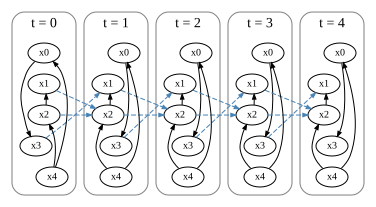

In [4]:
n_vars    = 5
n_lags    = 1
T         = 5
n_samples = 1000
edge_prob = 0.5

# Adjust the probability so that the expected number of lagged edges matches that of instantaneous edges.
lag_edge_prob = edge_prob * (n_vars - 1) / (2 * n_lags * n_vars)

rng = np.random.default_rng(seed)

causal_order = generate_causal_order(n_vars, rng)
B_true = generate_dag(n_vars, causal_order, edge_prob, rng)
A_true = generate_lag_graph(n_lags, n_vars, lag_edge_prob, rng)

labels = [f"x{i}" for i in range(n_vars)]
print("Causal order:", causal_order)

X_list = generate_longitudinal_data(
    [B_true], [A_true], causal_order, n_samples, T, n_lags, rng
)
print(f"\nGenerated {len(X_list)} time points, each shape = {X_list[0].shape}")

make_longitudinal_dot([B_true], [A_true], T, n_lags, labels=labels)

### Causal Discovery

To run causal discovery, we create a ``LongitudinalRESIT`` object and call the ``fit()`` method, with an option to estimate a causal graph that is **shared across all time points**.

* **is_common_graph**: True

Estimated causal order: [4, 0, 2, 1, 3]


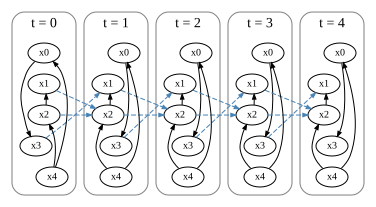

In [5]:
regressor = RandomForestRegressor(n_estimators=100, random_state=seed)
model = lingam.LongitudinalRESIT(
    regressor=regressor,
    n_lags=n_lags,
    is_common_graph=True,
)
model.fit(X_list)

print("Estimated causal order:", model.causal_order_)

make_longitudinal_dot(model.B_list_, model.A_list_, T, n_lags, labels=labels)

### Bootstrapping
We call ``bootstrap()`` method instead of ``fit()``. Here, the second argument specifies the number of bootstrap sampling.

In [6]:
n_sampling = 100
result = model.bootstrap(X_list, n_sampling=n_sampling)

print("Estimated causal order:")
for i, order in enumerate(result.causal_orders_):
    print(f"  #{i}: {order}")
    if i==10:
        break
print(" ... omitted remaining causal orders")

Estimated causal order:
  #0: [4, 2, 0, 1, 3]
  #1: [4, 2, 1, 0, 3]
  #2: [4, 2, 1, 3, 0]
  #3: [2, 4, 1, 0, 3]
  #4: [2, 4, 3, 0, 1]
  #5: [4, 2, 0, 3, 1]
  #6: [4, 3, 0, 2, 1]
  #7: [2, 4, 3, 0, 1]
  #8: [4, 2, 1, 0, 3]
  #9: [4, 0, 2, 1, 3]
  #10: [1, 2, 0, 4, 3]
 ... omitted remaining causal orders


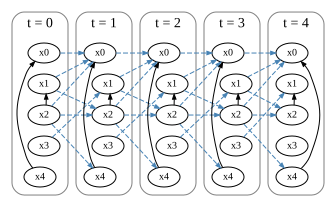

In [7]:
probs = result.get_probabilities()
B_list, A_list = split_adjacency_matrices(probs, n_lags=n_lags)

B_list = np.where(B_list > 0.8, 1.0, 0.0)
A_list = np.where(A_list > 0.8, 1.0, 0.0)

labels = [f"x{i}" for i in range(n_vars)]
make_longitudinal_dot(B_list, A_list, T, n_lags, labels=labels)

### Visualization of nonlinear causal effect

To estimate causal effects, we convert `X_list` into a pandas DataFrame and **assign the variable names as column headers**.

In [8]:
df = pd.concat(
    [
        pd.DataFrame(X, columns=[f"x{i}({t})" for i in range(X.shape[1])])
        for t, X in enumerate(X_list)
    ],
    axis=1
)
df.head()

,x0(0),x1(0),x2(0),x3(0),x4(0),x0(1),x1(1),x2(1),x3(1),x4(1),...,x0(3),x1(3),x2(3),x3(3),x4(3),x0(4),x1(4),x2(4),x3(4),x4(4)
0,0.641843,-0.196037,-0.760259,0.943723,-0.210342,0.641680,1.151756,0.047097,0.132253,0.737887,...,-1.046077,-1.706451,-0.449070,0.099102,-0.607881,0.595089,-1.154275,-2.204767,0.604495,-0.222083
1,0.801771,1.273976,-0.206553,0.241374,0.755527,0.833944,0.441442,1.801890,0.960040,0.827800,...,0.037223,0.909477,0.982044,0.489363,0.376430,1.113998,0.819565,1.832756,0.304971,0.432405
2,0.498402,0.661822,-2.144982,0.312457,-0.426441,-0.392322,-0.034070,-0.907412,-0.481157,-0.683781,...,-0.107162,-0.678223,-0.578209,-0.100517,-0.132903,-0.079066,-0.627244,-1.318024,-1.029641,0.042229
3,0.475097,0.874595,0.577764,1.000082,-0.737984,-0.546033,1.842460,1.213513,-1.217201,-0.709243,...,-0.498157,-1.267601,-0.359210,-0.545929,-0.746147,-1.311535,-0.227648,-1.950224,0.048537,-0.686330
4,0.515337,0.703391,0.166942,-0.630068,-0.099630,-0.314588,-0.746313,0.947151,0.001698,-0.331994,...,-0.767589,-0.821303,-1.996743,0.222484,-0.331620,0.579516,-1.146316,-1.853734,0.133095,0.649914


Next, we reconstruct the bootstrap adjacency matrix and create a new `BootstrapResult`.

In [9]:
am_list = []
for am in result._adjacency_matrices_list:
    am_list.append(make_single_adjacency_matrix(am, n_vars, n_lags))
bo_res = lingam.BootstrapResult(am_list, None, result.resampled_indices_)

Then, we visualize the estimated nonlinear causal effect from **x2(t=1)** to **x2(t=3)**.

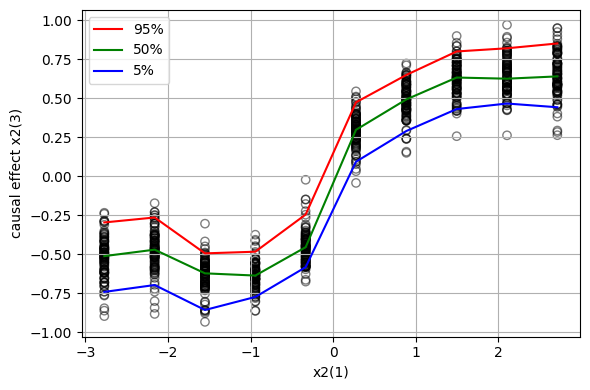

In [10]:
fig = plt.figure(figsize=(6, 4))
fig = visualize_nonlinear_causal_effect(df, bo_res, RandomForestRegressor(), "x2(1)", "x2(3)", fig=fig)

for ax in fig.get_axes():
    ax.legend()
    ax.grid()

fig.tight_layout()
fig.show()